# 0. Vertical and Horizontal Accuracies in SubGrid Corrections

Coastal cities like Norfolk, Virginia, face increasing flood risks due to sea-level rise, storm surge, and tidal variability. Accurate flood modeling is essential for planning, mitigation, and emergency response. One way to improve these models is by applying SubGrid corrections, which allow fine-scale features of the landscape (such as channels, embankments, and small-scale topography) to influence flooding dynamics, even when the overall model grid is relatively coarse.

In this tutorial, we explore how both vertical accuracy (through higher-resolution phi levels and SubGrid levels in the water column) and horizontal accuracy (through finer-resolution Digital Elevation Models, or DEMs) affect flood predictions. Using a region of the Chesapeake Bay as a case study, we begin by examining how DEM resolution alters the computed wet area fraction. We then show how refining the representation of the water column can capture important variations in depth and flow pathways that may otherwise be overlooked.

This Jupyter Notebook is designed as a practical, step-by-step guide for working with SubGrid ADCIRC preprocessing outputs. By the end, you should be able to:

    - Understand how DEM resolution influences modeled wetting and drying.
    - Recognize the role of phi levels and SubGrid levels in representing vertical variability.

By connecting these concepts, you’ll gain both a conceptual and practical understanding of how resolution choices directly impact the reliability of coastal flood modeling.

### Import Libraries and Path to Output Folders 

First, set up your local environment to run the SubGrid tools. If you haven’t already, install the required modules and packages in the same environment where this notebook will run. Next, define the correct path to your output directory. This is where all generated files from the code will be saved!


In [5]:
import sys
## this needs to be the path to the src/AdcircSubgrid
sys.path.append(r'T:\Projects\2016-2020-DHS-CRCoE\Molly\adcirc-subgrid\src\AdcircSubgrid')     # Path to output folders 
#sys.path.append(r'C:\Users\jsknowle\Documents\PyCharm\subGrid\Norfolk')                                 # Path to output folders 
import os
import mesh_plot
import matplotlib.pyplot as plt
import netCDF4 as nc
import numpy as np
import matplotlib.image as mpimg

### 1. Horizontal Accuracies  - DEM Resoltuions

Here we establish the base DEM in order to evaluate the impact of horizontal resolution on SubGrid performance. Horizontal accuracy refers to how well the grid spacing of the DEM represents fine-scale land and channel features that control water movement and inundation. A coarser DEM may smooth over important details such as narrow channels, levees, or small elevation changes, while a finer DEM can capture these features more precisely, but at the cost of higher computational demand.

To demonstrate this, we first run SubGrid with a 30 m DEM as our baseline. We then compare the resulting wetFraction values spatially against simulations using a 10 m DEM (higher resolution) and a 100 m DEM (lower resolution). This allows us to assess how differences in horizontal resolution influence floodplain representation and highlight the trade-offs between model accuracy and efficiency.
 

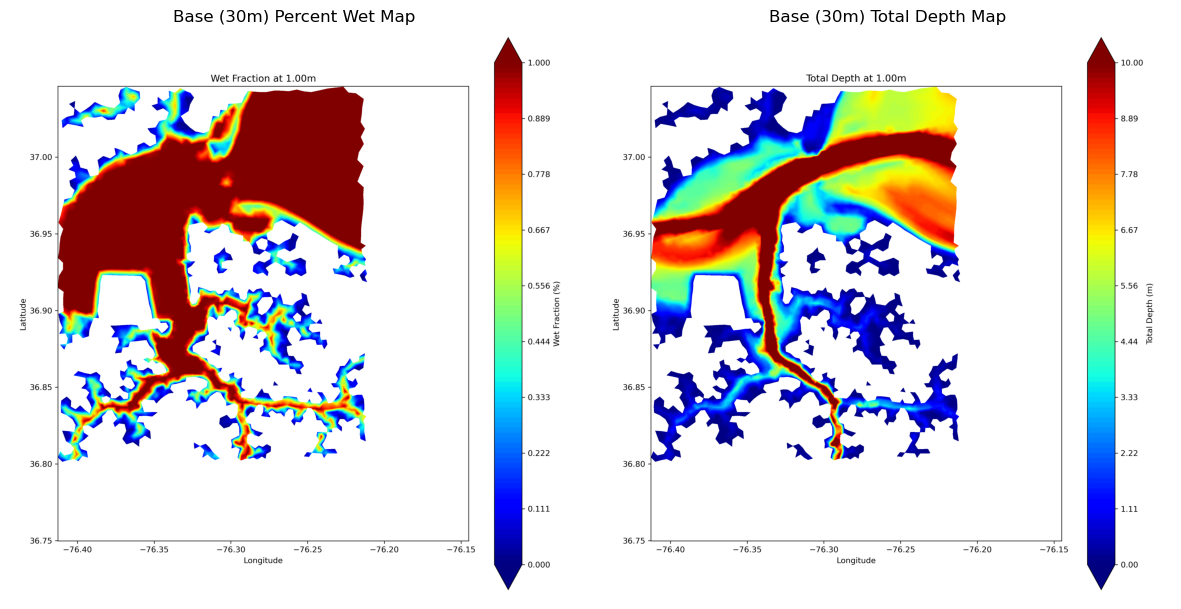

In [6]:
# -----------------------------
# Define file paths
# -----------------------------
# Path to the ADCIRC mesh file (.fort.14), which defines the grid geometry
#mesh_data = r"C:\Users\jsknowle\Documents\PyCharm\subGrid\Norfolk\Input\HSOFS_fort.14"
mesh_data = r"Input\DEM\HSOFS_fort.14"


# Path to the 30m SubGrid DEM output (NetCDF format)
# This DEM is used to compute wet/dry areas and water depth at higher horizontal resolution
#dem30_nc = r"C:\Users\jsknowle\Documents\PyCharm\subGrid\Norfolk\Output\DEMs\subgrid30m.nc"
dem30_nc = r"Output\DEMs\subgrid30m.nc"
# Runtime in sec (can be used for labeling plots or time-based analyses)
runtime30 = 38

# -----------------------------
# Generate SubGrid mesh plots
# -----------------------------
# Plot the "percent_wet" variable: represents the fraction of each grid cell that is wet
# This metric helps assess which areas are inundated and shows how DEM resolution affects wet area distribution
# Arguments: NetCDF file, variable name, timestep index, show plot (True/False), output path for saved image
fig1_30 = mesh_plot.plot_mesh(dem30_nc, 'percent_wet', 1, False, "Output/Plots/percentwet30_1m")

# Plot the "total_depth" variable: represents water depth at each node or cell
# Total depth is critical for understanding flood severity and identifying areas with shallow vs. deep flooding
fig2_30 = mesh_plot.plot_mesh(dem30_nc, 'total_depth', 1, False, "Output/Plots/totDepth30_1m")

# -----------------------------
# Load saved plot images for display
# -----------------------------
img1 = mpimg.imread("Output/Plots/percentwet30_1m.png")
img2 = mpimg.imread("Output/Plots/totDepth30_1m.png")

# -----------------------------
# Display plots side by side
# -----------------------------
# Create a figure with 1 row and 2 columns to compare the two variables
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Display the percent wet map
axes[0].imshow(img1)  # Show image
axes[0].axis("off")   # Hide axes for a cleaner view
axes[0].set_title("Base (30m) Percent Wet Map")  # Add descriptive title

# Display the total depth map
axes[1].imshow(img2)
axes[1].axis("off")
axes[1].set_title("Base (30m) Total Depth Map")

# Adjust spacing to prevent overlap of images and titles
plt.tight_layout()

# Render the figure in the notebook
plt.show()


Now we compare the baseline results to those obtained with the other DEM resolutions. By examining the 10 m DEM, we can see how increased horizontal detail captures finer-scale topographic features that may influence localized flooding patterns. In contrast, the 100 m DEM provides a much coarser representation, which can smooth out critical features such as narrow channels, small ridges, or urban infrastructure. This comparison highlights how resolution choices affect the calculated wetFraction and helps us evaluate the trade-offs between computational cost and model accuracy.

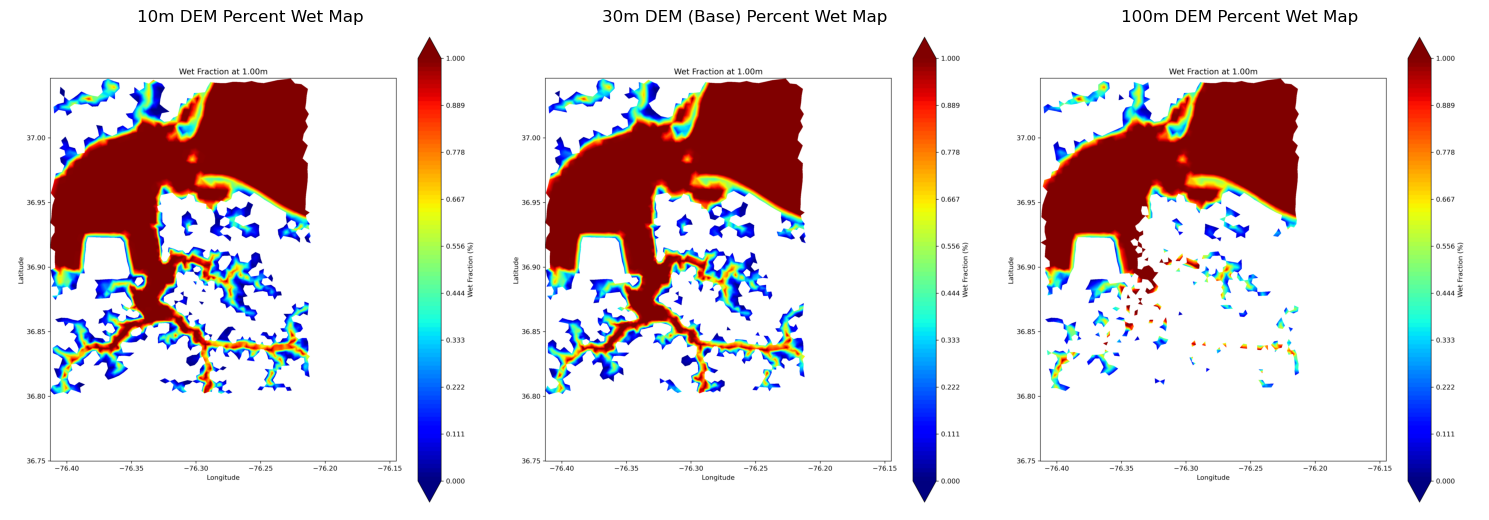

In [7]:
# -----------------------------
# Define file paths
# -----------------------------
# Path to the ADCIRC mesh file (.fort.14), which defines the grid geometry
#mesh_data = r"C:\Users\jsknowle\Documents\PyCharm\subGrid\Norfolk\Input\HSOFS_fort.14"
mesh_data = r"Input\DEM\HSOFS_fort.14"

# Paths to the SubGrid DEM outputs at different horizontal resolutions
# 10m DEM: high resolution for detailed flood mapping
#dem10_nc = r"C:\Users\jsknowle\Documents\PyCharm\subGrid\Norfolk\Output\DEMs\subgrid10m.nc"
dem10_nc = r"Output\DEMs\subgrid10m.nc"

# 100m DEM: coarse resolution for faster computation but less detail
#dem100_nc = r"C:\Users\jsknowle\Documents\PyCharm\subGrid\Norfolk\Output\DEMs\subgrid100m.nc"
dem100_nc = r"Output\DEMs\subgrid100m.nc"
# -----------------------------
# Generate percent wet plots for each DEM
# -----------------------------
# Percent wet represents the fraction of each grid cell that is inundated
# Higher percent_wet values indicate more water coverage in a cell

# Generate plot for 10m DEM
fig1_10 = mesh_plot.plot_mesh(dem10_nc, 'percent_wet', 1, False, "Output/Plots/percentwet10_1m")

# Generate plot for 100m DEM
fig1_100 = mesh_plot.plot_mesh(dem100_nc, 'percent_wet', 1, False, "Output/Plots/percentwet100_1m")

# -----------------------------
# Load images for side-by-side comparison
# -----------------------------
# Also load the 30m DEM (base case) previously generated
img1 = mpimg.imread("Output/Plots/percentwet10_1m.png")    # High-resolution DEM
img2 = mpimg.imread("Output/Plots/percentwet30_1m.png")    # Base DEM
img3 = mpimg.imread("Output/Plots/percentwet100_1m.png")   # Coarse-resolution DEM

# -----------------------------
# Create a 3-panel subplot figure to compare DEM resolutions
# -----------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 6))

# Display 10m DEM percent wet map
axes[0].imshow(img1)
axes[0].axis("off")  # Hide axes for cleaner visualization
axes[0].set_title("10m DEM Percent Wet Map")  # Descriptive title

# Display 30m DEM (base) percent wet map
axes[1].imshow(img2)
axes[1].axis("off")
axes[1].set_title("30m DEM (Base) Percent Wet Map")

# Display 100m DEM percent wet map
axes[2].imshow(img3)
axes[2].axis("off")
axes[2].set_title("100m DEM Percent Wet Map")

# Adjust layout to prevent overlap of titles and images
plt.tight_layout()

# -----------------------------
# Save the combined figure
# -----------------------------
# Ensure the output folder exists
os.makedirs("Output/Plots", exist_ok=True)

# Save the figure with high resolution for reporting or analysis
plt.savefig("Output/Plots/percentwet_comparisons.png", dpi=300)

# Show the figure in the notebook
plt.show()


Let’s zoom in on the Lafayette River, just south of Norfolk. This tidal tributary of the Elizabeth River flows through densely developed neighborhoods and is highly vulnerable to recurrent flooding. By focusing on this smaller region, we can better visualize how DEM resolution influences the representation of narrow channels, shoreline edges, and low-lying urban areas. Comparing the 10 m, 30 m, and 100 m DEM outputs here will make it easier to see where finer detail improves wetFraction estimates and where coarser resolution may miss or oversimplify important features.

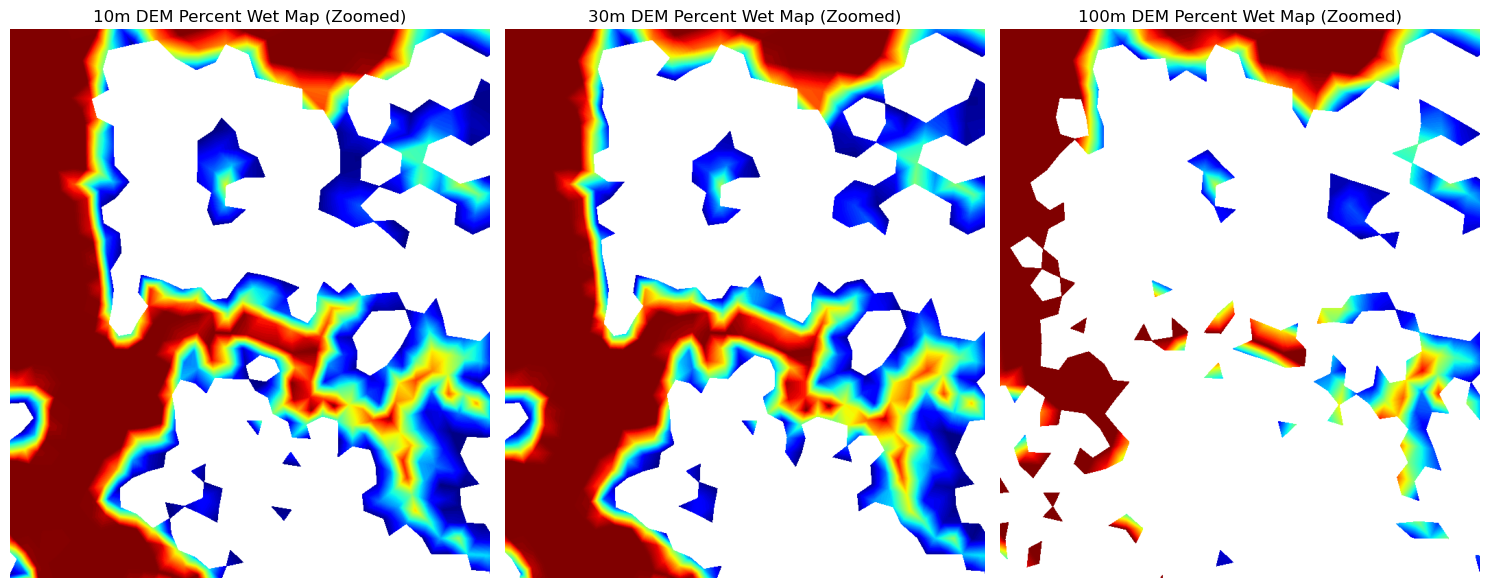

In [8]:
# -----------------------------
# Import necessary libraries
# -----------------------------
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# -----------------------------
# Load previously saved percent wet images
# -----------------------------
# These images were generated from different DEM resolutions (10m, 30m, 100m)
# They show the fraction of each grid cell that is inundated
img1 = mpimg.imread("Output/Plots/percentwet10_1m.png")    # High-resolution DEM
img2 = mpimg.imread("Output/Plots/percentwet30_1m.png")    # Base DEM
img3 = mpimg.imread("Output/Plots/percentwet100_1m.png")   # Coarse-resolution DEM

# -----------------------------
# Define cropping window (pixel coordinates)
# -----------------------------
# Zoom in on a region of interest, here Willoughby Bay.
# Adjust x_min, x_max, y_min, y_max until the area is centered correctly.
# Note: Image coordinates start at the top-left, so y-axis is inverted when plotting.
crop_box = {
    "x_min": 800,    # left boundary of crop
    "x_max": 1500,   # right boundary of crop
    "y_min": 1000,   # bottom boundary of crop
    "y_max": 1800    # top boundary of crop
}

# -----------------------------
# Create figure with 3 side-by-side subplots
# -----------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 6))

# --- Display 10m DEM zoomed view ---
axes[0].imshow(img1)
axes[0].set_xlim(crop_box["x_min"], crop_box["x_max"])     # crop x-axis
axes[0].set_ylim(crop_box["y_max"], crop_box["y_min"])     # crop y-axis and invert
axes[0].axis("off")                                        # hide axes for clarity
axes[0].set_title("10m DEM Percent Wet Map (Zoomed)")

# --- Display 30m DEM zoomed view ---
axes[1].imshow(img2)
axes[1].set_xlim(crop_box["x_min"], crop_box["x_max"])
axes[1].set_ylim(crop_box["y_max"], crop_box["y_min"])
axes[1].axis("off")
axes[1].set_title("30m DEM Percent Wet Map (Zoomed)")

# --- Display 100m DEM zoomed view ---
axes[2].imshow(img3)
axes[2].set_xlim(crop_box["x_min"], crop_box["x_max"])
axes[2].set_ylim(crop_box["y_max"], crop_box["y_min"])
axes[2].axis("off")
axes[2].set_title("100m DEM Percent Wet Map (Zoomed)")

# Adjust layout to prevent overlap
plt.tight_layout()

# -----------------------------
# Save combined zoomed figure
# -----------------------------
os.makedirs("Output/Plots", exist_ok=True)  # ensure output folder exists
plt.savefig("Output/Plots/percentwet_comparisons_zoomed.png", dpi=300)

# Display the figure in the notebook
plt.show()


Now we compare the statistics of total water depth across the full grid to evaluate how horizontal resolution influences modeled inundation. To illustrate this at a local scale, we focus on Node 3675, located within a floodplain of the Lafayette River, just south of the City of Norfolk (longitude –76.30, latitude 36.90). This point is of particular interest because floodplains are sensitive to subtle changes in elevation representation — a finer DEM may capture shallow depressions and channel connectivity that a coarser DEM smooths out. By examining water depth at this node under different DEM resolutions (10 m, 30 m, and 100 m), we can assess how resolution impacts localized flooding predictions and quantify differences in the model’s vertical accuracy.

In [9]:
!adcirc-subgrid plot-node --filename "Output/DEMs/subgrid10m.nc" --node 3675 --basis wse --save Output/Plots/node_10m_analysis.png
!adcirc-subgrid plot-node --filename "Output/DEMs/subgrid30m.nc" --node 3675 --basis wse --save Output/Plots/node_30m_analysis.png
!adcirc-subgrid plot-node --filename "Output/DEMs/subgrid100m.nc" --node 3675 --basis wse --save Output/Plots/node_100m_analysis.png

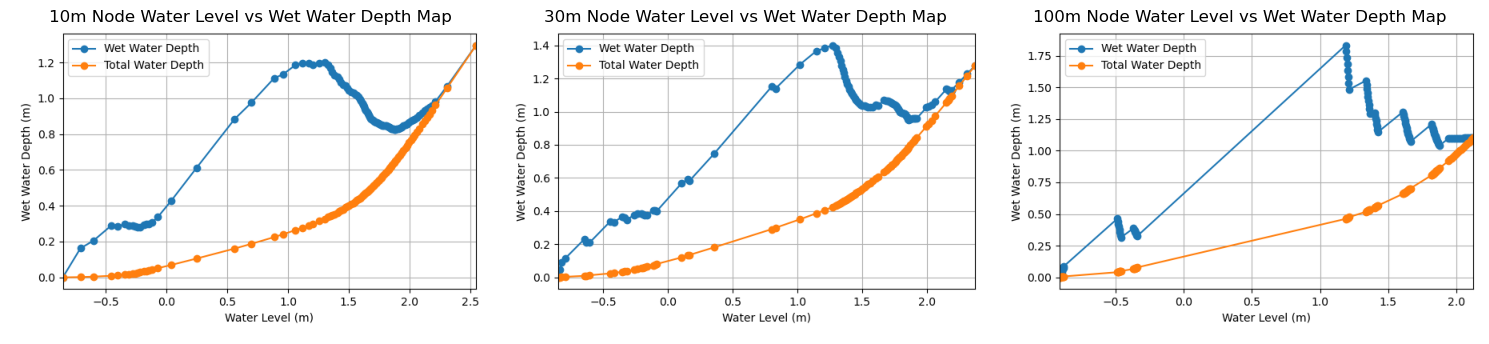

In [10]:
#### Code Missing 
img1 = mpimg.imread("Output/Plots/node_10m_analysis.png")
img2 = mpimg.imread("Output/Plots/node_30m_analysis.png")
img3 = mpimg.imread("Output/Plots/node_100m_analysis.png")

#Format: x_min, x_max, y_min, y_max
crop_box = {
    "x_min": 0,   # adjust this
    "x_max": 600,  # adjust this
    "y_min": 40,   # adjust this
    "y_max": 420   # adjust this
}

# --- Create figure with cropped images ---
fig, axes = plt.subplots(1, 3, figsize=(15, 6))

# 10m DEM
axes[0].imshow(img1)
axes[0].set_xlim(crop_box["x_min"], crop_box["x_max"])
axes[0].set_ylim(crop_box["y_max"], crop_box["y_min"])  # invert y
axes[0].axis("off")
axes[0].set_title("10m Node Water Level vs Wet Water Depth Map")

# 30m DEM
axes[1].imshow(img2)
axes[1].set_xlim(crop_box["x_min"], crop_box["x_max"])
axes[1].set_ylim(crop_box["y_max"], crop_box["y_min"])
axes[1].axis("off")
axes[1].set_title("30m Node Water Level vs Wet Water Depth Map")

# 100m DEM
axes[2].imshow(img3)
axes[2].set_xlim(crop_box["x_min"], crop_box["x_max"])
axes[2].set_ylim(crop_box["y_max"], crop_box["y_min"])
axes[2].axis("off")
axes[2].set_title("100m Node Water Level vs Wet Water Depth Map")

plt.tight_layout()

# Save combined figure
os.makedirs("Output/Plots", exist_ok=True)
plt.savefig("Output/Plots/node_wse_comparisons_zoomed.png", dpi=300)

Now that we have examined the differences in water depth around the Lafayette River, we expand our view to the entire computational mesh. While local comparisons highlight how resolution affects flooding in specific floodplains and channels, analyzing the full mesh allows us to capture system-wide impacts of DEM resolution.

Here, we compare the statistics of total water depth over the entire mesh for the 10 m, 30 m, and 100 m DEM cases. This broader comparison helps identify whether resolution primarily affects localized flooding features or if it also introduces systematic differences in basin-wide water depth distributions. By looking at averages and other statistical measures, we can quantify how much accuracy is gained (or lost) with finer or coarser DEMs and better understand the trade-offs between computational efficiency and hydrodynamic realism.

In [11]:
# -----------------------------
# Import required libraries
# -----------------------------
import netCDF4 as nc      # For reading netCDF files (DEM outputs)
import numpy as np        # For numerical operations

# -----------------------------
# Read mesh file (.fort.14)
# -----------------------------
# This reads basic mesh information such as number of elements and vertices,
# as well as the node coordinates (longitude, latitude) and depths.
# Useful if you need to reference node positions or check mesh consistency.
mesh_data = r"Input\DEM\HSOFS_fort.14"

with open(mesh_data) as f14:
    f14.readline()  # skip the first header line
    numElem, numVert = map(int, f14.readline().split())  # read number of elements and vertices
    lon, lat, dep = np.loadtxt(f14, usecols=(1, 2, 3), unpack=True, max_rows=numVert)  # read vertex coordinates and depth

print(f"Read {numVert} vertices from mesh.")

# -----------------------------
# Define list of DEM netCDF files to compare
# -----------------------------
# These are the different horizontal resolutions we want to analyze.
nc_files = {
    "10m": r"Output\DEMs\subgrid10m.nc",
    "30m": r"Output\DEMs\subgrid30m.nc",
    "100m": r"Output\DEMs\subgrid100m.nc",
}

# -----------------------------
# Function to compute statistics from a DEM netCDF file
# -----------------------------
# This function reads the total water depth at each node and calculates:
# 1. Overall mean total depth (average flooding)
# 2. Maximum total depth (peak flooding)
def compute_statistics(nc_file):
    with nc.Dataset(nc_file) as ds:
        # Access the total water depth variable at vertices
        total_depth_var = ds.variables['gridTotWatDepthVertex']
        fill_value = getattr(total_depth_var, '_FillValue', -99999)  # get fill value if defined
        total_depth_data = total_depth_var[:]  # read all data

    # Ensure shape is (time, nodes); if 1D, add a new axis
    if total_depth_data.ndim == 1:
        total_depth_data = total_depth_data[np.newaxis, :]

    # Mask invalid data (NaNs, fill values, or extreme negative values)
    masked_data = np.ma.masked_invalid(total_depth_data)
    masked_data = np.ma.masked_where(
        (masked_data <= -99990) | (masked_data == fill_value), masked_data
    )

    # Calculate per-timestep statistics
    capHavg = masked_data.mean(axis=1).filled(np.nan)  # average depth per timestep
    capHmax = masked_data.max(axis=1).filled(np.nan)   # maximum depth per timestep

    # Filter out NaN results to ensure valid calculations
    valid_avgs = capHavg[~np.isnan(capHavg)]
    valid_maxs = capHmax[~np.isnan(capHmax)]

    if valid_avgs.size and valid_maxs.size:
        return {
            "Average Depth (overall mean)": float(valid_avgs.mean()),  # mean over all timesteps
            "Max Depth (overall max)": float(valid_maxs.max())          # max over all timesteps
        }
    else:
        return None  # no valid data found

# -----------------------------
# Compute and compare statistics for all DEM resolutions
# -----------------------------
print("\n--- Statistics Comparison ---")
for label, filepath in nc_files.items():
    stats = compute_statistics(filepath)
    if stats:
        print(f"\n{label} grid ({filepath}):")
        print(f"  Average Total Depth = {stats['Average Depth (overall mean)']:.3f} m")
        print(f"  Max Total Depth     = {stats['Max Depth (overall max)']:.3f} m")
    else:
        print(f"\n{label} grid ({filepath}): No valid data found.")


Read 6306 vertices from mesh.

--- Statistics Comparison ---

10m grid (Output\DEMs\subgrid10m.nc):
  Average Total Depth = 0.599 m
  Max Total Depth     = 21.665 m

30m grid (Output\DEMs\subgrid30m.nc):
  Average Total Depth = 0.608 m
  Max Total Depth     = 18.640 m

100m grid (Output\DEMs\subgrid100m.nc):
  Average Total Depth = 0.600 m
  Max Total Depth     = 15.789 m


### 2. Vertical Accuracies  - Phi Levels

In this section, we examine how vertical resolution affects SubGrid ADCIRC simulations by analyzing phi levels, which define the vertical discretization of the water column. Vertical accuracy is important because it influences how well the model captures water depth variations, stratification, and inundation in both shallow and deep areas.

We begin by establishing a baseline simulation with 50 phi levels on a 10 m horizontal DEM. This provides a reference case with relatively fine vertical resolution. Next, we perform the same analysis using 25 phi levels (lower vertical resolution) and 100 phi levels (higher vertical resolution), both also on the 10 m DEM. By comparing the resulting wetFraction (fraction of each cell that is wet) and total water depth across these different phi levels, we can evaluate how vertical resolution affects the representation of inundation and peak water depth.

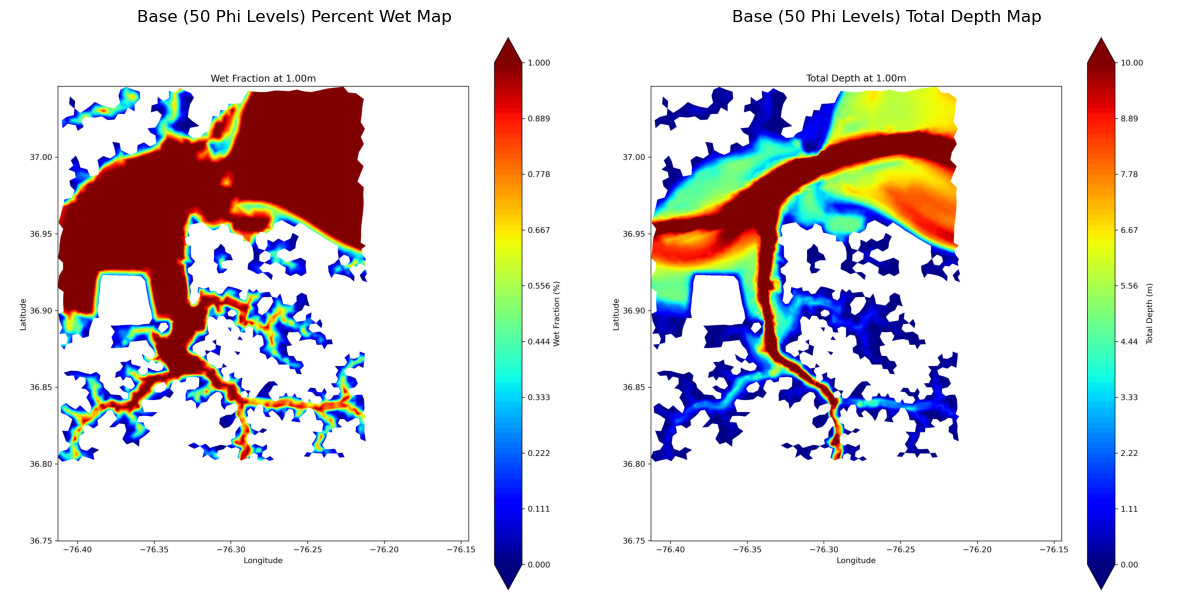

In [12]:
# -----------------------------
# Define file paths
# -----------------------------
# Mesh file (.fort.14) defines the grid geometry
mesh_data = r"Input\DEM\HSOFS_fort.14"

# NetCDF output for SubGrid simulation using 50 phi levels
# Phi levels represent the vertical discretization of the water column
# Increasing phi levels generally improves vertical accuracy of water depth calculations
phi50_nc = r"Output\PhiLevels\subgrid_10m_50.nc"

# Runtime in sec, can be used for labeling or analysis
runtime30 = 38

# -----------------------------
# Generate SubGrid mesh plots
# -----------------------------
# Plot 'percent_wet' to visualize the fraction of each cell that is inundated
fig1_30 = mesh_plot.plot_mesh(phi50_nc, 'percent_wet', 1, False, "Output/Plots/percentwet_p50_1m")

# Plot 'total_depth' to visualize water depth at each node
fig2_30 = mesh_plot.plot_mesh(phi50_nc, 'total_depth', 1, False, "Output/Plots/totDepth_p50_1m")

# -----------------------------
# Load saved images for display
# -----------------------------
# These images were generated in the previous step
img1 = mpimg.imread("Output/Plots/percentwet_p50_1m.png")
img2 = mpimg.imread("Output/Plots/totDepth_p50_1m.png")

# -----------------------------
# Create side-by-side subplot for comparison
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Display the percent wet map
axes[0].imshow(img1)                     # Show the image
axes[0].axis("off")                      # Hide axes for cleaner visualization
axes[0].set_title("Base (50 Phi Levels) Percent Wet Map")  # Add descriptive title

# Display the total depth map
axes[1].imshow(img2)
axes[1].axis("off")
axes[1].set_title("Base (50 Phi Levels) Total Depth Map")

# Adjust layout to prevent overlap of titles and images
plt.tight_layout()

# Render the figure in the notebook
plt.show()


Now we compare the baseline 50 phi level simulation to the other vertical resolutions (25 and 100 phi levels) to understand how vertical discretization affects flooding predictions. By examining the percent wet maps side by side, we can see how lower phi levels (25) may underestimate inundation in shallow areas or fail to capture fine-scale vertical variations, while higher phi levels (100) provide a more detailed representation of water depth and wetting/drying dynamics.

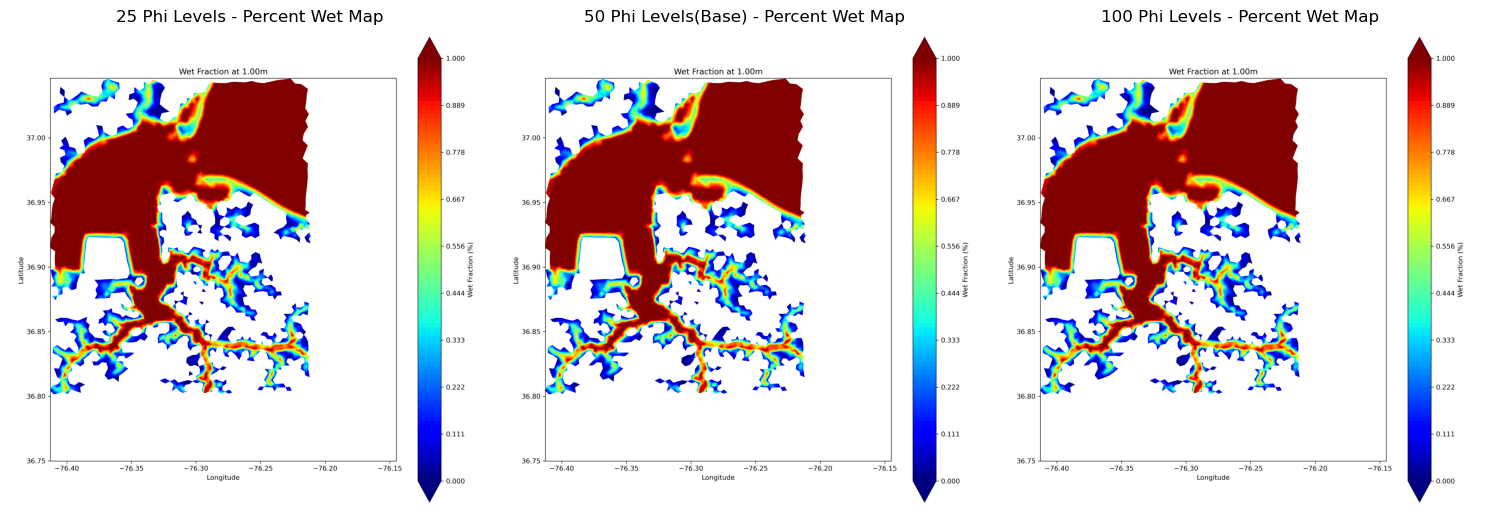

In [14]:
# NetCDF outputs for different vertical resolutions (phi levels) on the same 10m DEM
# Phi levels represent the vertical discretization of the water column
phi25_nc = r"Output\PhiLevels\subgrid_10m_25.nc"   # 25 phi levels
phi100_nc = r"Output\PhiLevels\subgrid_10m_100.nc" # 100 phi levels

# -----------------------------
# Generate percent wet plots for different phi levels
# -----------------------------
# percent_wet represents the fraction of each grid cell that is inundated
# This visualization helps evaluate how vertical resolution affects inundation patterns

# Plot for 25 phi levels
fig1_25 = mesh_plot.plot_mesh(phi25_nc, 'percent_wet', 1, False, "Output/Plots/percentwet_p25_1m")

# Plot for 100 phi levels
fig1_100 = mesh_plot.plot_mesh(phi100_nc, 'percent_wet', 1, False, "Output/Plots/percentwet_p100_1m")

# -----------------------------
# Load saved images for display
# -----------------------------
# Include the 50 phi level (base) image for side-by-side comparison
img1 = mpimg.imread("Output/Plots/percentwet_p25_1m.png")    # Low vertical resolution
img2 = mpimg.imread("Output/Plots/percentwet_p50_1m.png")    # Base vertical resolution
img3 = mpimg.imread("Output/Plots/percentwet_p100_1m.png")   # High vertical resolution

# -----------------------------
# Create a 3-panel subplot figure for comparison
# -----------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 6))

# Display 25 phi levels
axes[0].imshow(img1)
axes[0].axis("off")  # Hide axes for cleaner visualization
axes[0].set_title("25 Phi Levels - Percent Wet Map")

# Display 50 phi levels (base)
axes[1].imshow(img2)
axes[1].axis("off")
axes[1].set_title("50 Phi Levels(Base) - Percent Wet Map")

# Display 100 phi levels
axes[2].imshow(img3)
axes[2].axis("off")
axes[2].set_title("100 Phi Levels - Percent Wet Map")

# Adjust layout to prevent overlap of titles and images
plt.tight_layout()

# -----------------------------
# Save the combined figure
# -----------------------------
# Ensure the output folder exists
os.makedirs("Output/Plots", exist_ok=True)

# Save figure with high resolution for reporting or analysis
plt.savefig("Output/Plots/percentwet_Phi_comparisons.png", dpi=300)

# Display the figure in the notebook
plt.show()


Let’s zoom in on the Lafayette River, just south of Norfolk, to explore how changes in phi levels affect vertical resolution in the SubGrid model. This area is a good test case because the river and its surrounding floodplain experience frequent tidal flooding and have a mix of deep channels and shallow low-lying land.

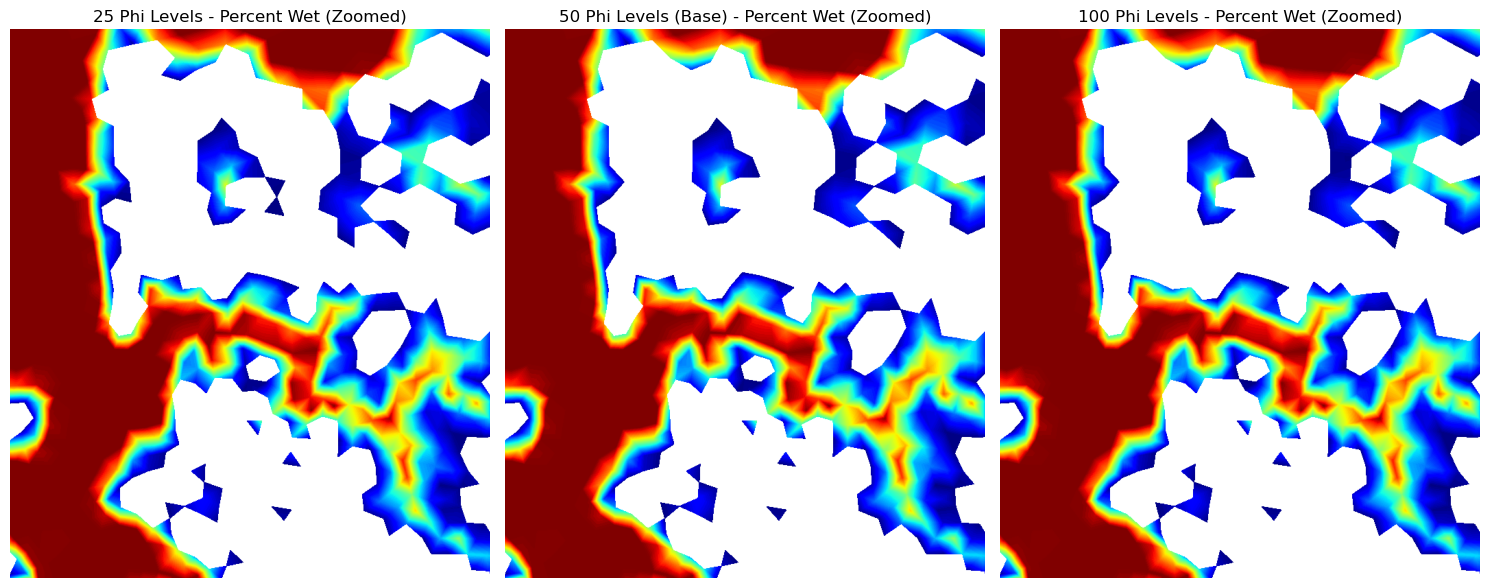

In [15]:

# --- Load images generated from earlier SubGrid runs ---
# These PNGs show the percent wet maps at different phi levels (25, 50, 100).
# By loading them directly, we can manipulate and crop them without re-running the model.
img1 = mpimg.imread("Output/Plots/percentwet_p25_1m.png")   # 25 phi levels
img2 = mpimg.imread("Output/Plots/percentwet_p50_1m.png")   # 50 phi levels (baseline)
img3 = mpimg.imread("Output/Plots/percentwet_p100_1m.png")  # 100 phi levels

# --- Define cropping window (in pixels) ---
# Cropping is useful to zoom into a smaller region (e.g., Willoughby Bay near Norfolk).
# Coordinates here are in pixel space, not lat/lon.
# Adjust these values until the region of interest is centered.
crop_box = {
    "x_min": 800,    # left boundary of crop
    "x_max": 1500,   # right boundary of crop
    "y_min": 1000,   # top boundary of crop
    "y_max": 1800    # bottom boundary of crop
}

# --- Create figure with 3 side-by-side panels ---
# We want to visually compare how different phi levels (vertical resolutions)
# affect the spatial distribution of percent wetness.
fig, axes = plt.subplots(1, 3, figsize=(15, 6))

# --- Plot 25 Phi Levels ---
# Apply the cropping box to "zoom in" on the region of interest.
axes[0].imshow(img1)
axes[0].set_xlim(crop_box["x_min"], crop_box["x_max"])   # crop horizontally
axes[0].set_ylim(crop_box["y_max"], crop_box["y_min"])   # crop vertically (note y-axis inverted)
axes[0].axis("off")                                      # hide axes ticks for cleaner look
axes[0].set_title("25 Phi Levels - Percent Wet (Zoomed)")

# --- Plot 50 Phi Levels (Baseline) ---
axes[1].imshow(img2)
axes[1].set_xlim(crop_box["x_min"], crop_box["x_max"])
axes[1].set_ylim(crop_box["y_max"], crop_box["y_min"])
axes[1].axis("off")
axes[1].set_title("50 Phi Levels (Base) - Percent Wet (Zoomed)")

# --- Plot 100 Phi Levels ---
axes[2].imshow(img3)
axes[2].set_xlim(crop_box["x_min"], crop_box["x_max"])
axes[2].set_ylim(crop_box["y_max"], crop_box["y_min"])
axes[2].axis("off")
axes[2].set_title("100 Phi Levels - Percent Wet (Zoomed)")

# --- Adjust layout for better readability ---
plt.tight_layout()

# --- Save the final side-by-side comparison ---
# This creates a single figure with all three cropped maps, so you can
# include it in reports or papers. Saving at high resolution (dpi=300) is good for publication.
os.makedirs("Output/Plots", exist_ok=True)
plt.savefig("Output/Plots/percentwet_Phi_comparisons_zoomed.png", dpi=300)

# --- Display the figure interactively ---
plt.show()


Now we compare the statistics of total water depth in the full grid. Let's look node 3675 which is in a floodplain in the Lafayette River to the south of the city of Norfolk at at -76.30, 36.90. 

In [16]:
!adcirc-subgrid plot-node --filename "Output\PhiLevels\subgrid_10m_25.nc" --node 3675 --basis phi --save Output/Plots/node_phi_25_analysis.png
!adcirc-subgrid plot-node --filename "Output\PhiLevels\subgrid_10m_50.nc" --node 3675 --basis phi --save Output/Plots/node_phi_50_analysis.png
!adcirc-subgrid plot-node --filename "Output\PhiLevels\subgrid_10m_100.nc" --node 3675 --basis phi --save Output/Plots/node_phi_100_analysis.png

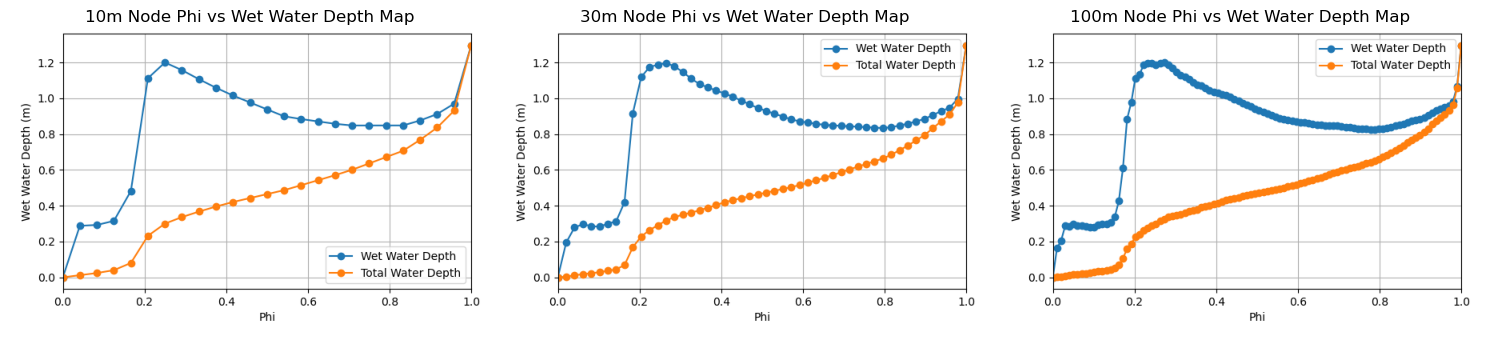

In [17]:
img1 = mpimg.imread("Output/Plots/node_phi_25_analysis.png")
img2 = mpimg.imread("Output/Plots/node_phi_50_analysis.png")
img3 = mpimg.imread("Output/Plots/node_phi_100_analysis.png")

#Format: x_min, x_max, y_min, y_max
crop_box = {
    "x_min": 0,   # adjust this
    "x_max": 600,  # adjust this
    "y_min": 40,   # adjust this
    "y_max": 420   # adjust this
}

# --- Create figure with cropped images ---
fig, axes = plt.subplots(1, 3, figsize=(15, 6))

# 10m DEM
axes[0].imshow(img1)
axes[0].set_xlim(crop_box["x_min"], crop_box["x_max"])
axes[0].set_ylim(crop_box["y_max"], crop_box["y_min"])  # invert y
axes[0].axis("off")
axes[0].set_title("10m Node Phi vs Wet Water Depth Map")

# 30m DEM
axes[1].imshow(img2)
axes[1].set_xlim(crop_box["x_min"], crop_box["x_max"])
axes[1].set_ylim(crop_box["y_max"], crop_box["y_min"])
axes[1].axis("off")
axes[1].set_title("30m Node Phi vs Wet Water Depth Map")

# 100m DEM
axes[2].imshow(img3)
axes[2].set_xlim(crop_box["x_min"], crop_box["x_max"])
axes[2].set_ylim(crop_box["y_max"], crop_box["y_min"])
axes[2].axis("off")
axes[2].set_title("100m Node Phi vs Wet Water Depth Map")

plt.tight_layout()

# Save combined figure
os.makedirs("Output/Plots", exist_ok=True)
plt.savefig("Output/Plots/node_phi_comparisons_zoomed.png", dpi=300)

Now that we can see the differences around the Lafayette River lets look at the entire mesh to determine how they differ in its average total water depth. Here we compare the statistics of total water depth over the mesh. 

In [18]:
with open(mesh_data) as f14:
    f14.readline()  
    numElem, numVert = map(int, f14.readline().split())
    lon, lat, dep = np.loadtxt(f14, usecols=(1, 2, 3), unpack=True, max_rows=numVert)

print(f"Read {numVert} vertices from mesh.")

# --- List of DEM netCDF files to compare ---
nc_files = {
    "p25": r"Output\PhiLevels\subgrid_10m_25.nc",
    "p50": r"Output\PhiLevels\subgrid_10m_50.nc",
    "p100": r"Output\PhiLevels\subgrid_10m_100.nc",
}

# --- Function to compute stats for a given netCDF file ---
def compute_statistics(nc_file):
    with nc.Dataset(nc_file) as ds:
        total_depth_var = ds.variables['gridTotWatDepthVertex']
        fill_value = getattr(total_depth_var, '_FillValue', -99999)
        total_depth_data = total_depth_var[:]

    # Ensure shape is (time, nodes)
    if total_depth_data.ndim == 1:
        total_depth_data = total_depth_data[np.newaxis, :]

    # Mask invalids
    masked_data = np.ma.masked_invalid(total_depth_data)
    masked_data = np.ma.masked_where(
        (masked_data <= -99990) | (masked_data == fill_value), masked_data
    )

    # Calculate statistics per snapshot
    capHavg = masked_data.mean(axis=1).filled(np.nan)
    capHmax = masked_data.max(axis=1).filled(np.nan)

    # Filter valid results
    valid_avgs = capHavg[~np.isnan(capHavg)]
    valid_maxs = capHmax[~np.isnan(capHmax)]

    if valid_avgs.size and valid_maxs.size:
        return {
            "Average Depth (overall mean)": float(valid_avgs.mean()),
            "Max Depth (overall max)": float(valid_maxs.max())
        }
    else:
        return None

# --- Run stats for all files ---
print("\n--- Statistics Comparison ---")
for label, filepath in nc_files.items():
    stats = compute_statistics(filepath)
    if stats:
        print(f"\n{label} grid ({filepath}):")
        print(f"  Average Total Depth = {stats['Average Depth (overall mean)']:.3f} m")
        print(f"  Max Total Depth     = {stats['Max Depth (overall max)']:.3f} m")
    else:
        print(f"\n{label} grid ({filepath}): No valid data found.")

Read 6306 vertices from mesh.

--- Statistics Comparison ---

p25 grid (Output\PhiLevels\subgrid_10m_25.nc):
  Average Total Depth = 0.631 m
  Max Total Depth     = 21.665 m

p50 grid (Output\PhiLevels\subgrid_10m_50.nc):
  Average Total Depth = 0.608 m
  Max Total Depth     = 21.665 m

p100 grid (Output\PhiLevels\subgrid_10m_100.nc):
  Average Total Depth = 0.599 m
  Max Total Depth     = 21.665 m
